# SR3

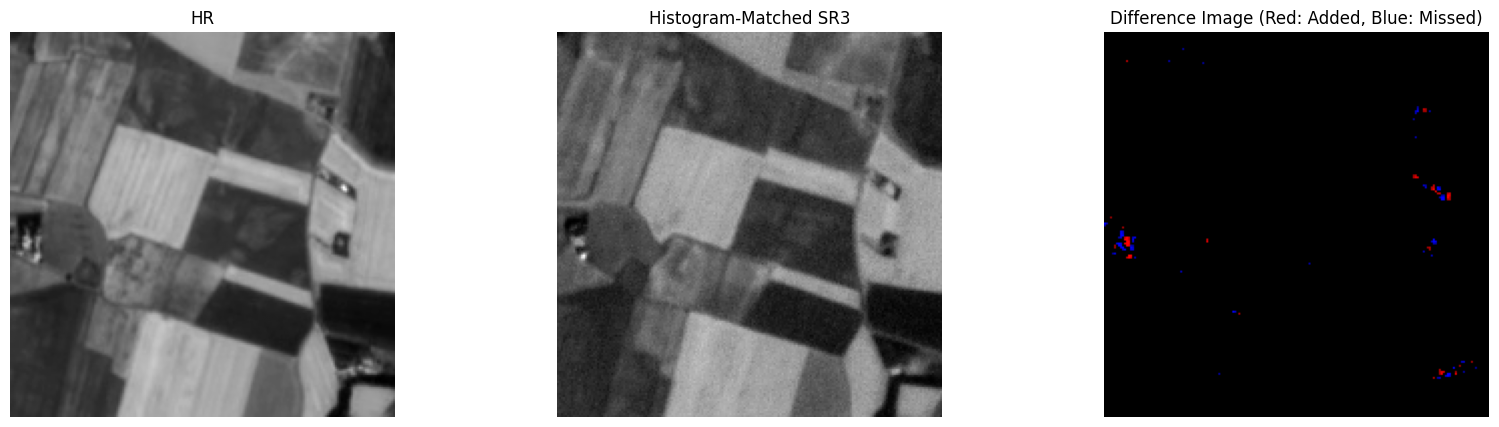

True

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from skimage import exposure
import os

img1 = cv2.imread('/content/1366_sr_sr3.png')
img2 = cv2.imread('/content/1366_hr.png')

# Apply histogram matching
# Convert the result to uint8 before converting to grayscale
matched_img1 = exposure.match_histograms(img1, img2).astype(np.uint8)

gray_img1 = cv2.cvtColor(matched_img1, cv2.COLOR_BGR2GRAY)
gray_img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Convert to signed for proper subtraction
matched_img1_signed = gray_img1.astype(np.int16)
gray_img2_signed = gray_img2.astype(np.int16)

# Subtract: SR - HR
diff_img =  gray_img2_signed - matched_img1_signed

threshold = 30  # Control threshold: only highlight |diff| > threshold (adjust as needed, e.g., 5-20 for noise filtering)

# Create color diff
color_diff = np.zeros((diff_img.shape[0], diff_img.shape[1], 3), dtype=np.uint8)
mask_added = diff_img > threshold   # Positive: added (red)
mask_missed = diff_img < -threshold # Negative: missed (blue)
color_diff[..., 2][mask_added] = np.clip(diff_img[mask_added] * 5, 0, 255)  # Red for added
color_diff[..., 0][mask_missed] = np.clip(-diff_img[mask_missed] * 5, 0, 255)  # Blue for missed

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].imshow(gray_img2, cmap='gray')
axes[0].set_title('HR')
axes[0].axis('off')

axes[1].imshow(gray_img1, cmap='gray')
axes[1].set_title('Histogram-Matched SR3')
axes[1].axis('off')

axes[2].imshow(color_diff)
axes[2].set_title('Difference Image (Red: Added, Blue: Missed)')
axes[2].axis('off')

plt.show()

# Create the results folder if it doesn't exist
results_folder = '/content/results'
if not os.path.exists(results_folder):
    os.makedirs(results_folder)

# Save the images
cv2.imwrite(os.path.join(results_folder, 'HR.png'), gray_img2)
cv2.imwrite(os.path.join(results_folder, 'Histogram-Matched_SR3.png'), gray_img1)
cv2.imwrite(os.path.join(results_folder, 'Difference_Image_SR3.png'), color_diff)

# DiWa

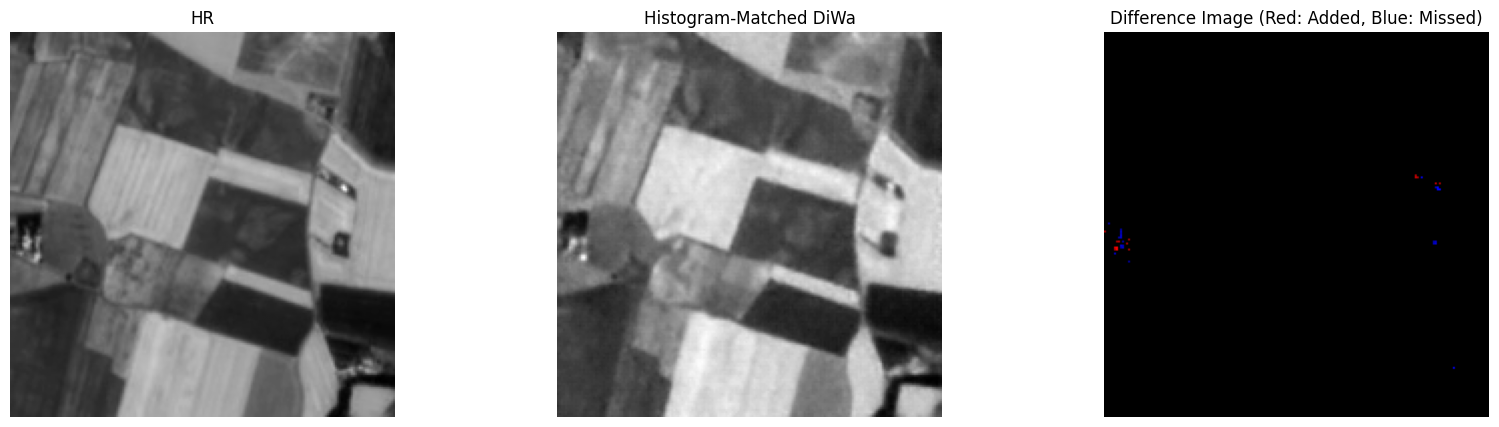

True

In [ ]:
from skimage import exposure

img1 = cv2.imread('/content/1366_sr_diwa.png')
img2 = cv2.imread('/content/1366_hr.png')

# Apply histogram matching
# Convert the result to uint8 before converting to grayscale
matched_img1 = exposure.match_histograms(img1, img2).astype(np.uint8)

gray_img1 = cv2.cvtColor(matched_img1, cv2.COLOR_BGR2GRAY)
gray_img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

# Convert to signed for proper subtraction
matched_img1_signed = gray_img1.astype(np.int16)
gray_img2_signed = gray_img2.astype(np.int16)

# Subtract: HR - SR
diff_img =  gray_img2_signed - matched_img1_signed

threshold = 30  # Control threshold: only highlight |diff| > threshold (adjust as needed, e.g., 5-20 for noise filtering)

# Create color diff
color_diff = np.zeros((diff_img.shape[0], diff_img.shape[1], 3), dtype=np.uint8)
mask_added = diff_img > threshold   # Positive: added (red)
mask_missed = diff_img < -threshold # Negative: missed (blue)
color_diff[..., 2][mask_added] = np.clip(diff_img[mask_added] * 5, 0, 255)  # Red for added
color_diff[..., 0][mask_missed] = np.clip(-diff_img[mask_missed] * 5, 0, 255)  # Blue for missed

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

axes[0].imshow(gray_img2, cmap='gray')
axes[0].set_title('HR')
axes[0].axis('off')

axes[1].imshow(gray_img1, cmap='gray')
axes[1].set_title('Histogram-Matched DiWa')
axes[1].axis('off')

axes[2].imshow(color_diff)
axes[2].set_title('Difference Image (Red: Added, Blue: Missed)')
axes[2].axis('off')

plt.show()

# Save the images
cv2.imwrite(os.path.join(results_folder, 'HR.png'), gray_img2)
cv2.imwrite(os.path.join(results_folder, 'Histogram-Matched_DiWa.png'), gray_img1)
cv2.imwrite(os.path.join(results_folder, 'Difference_Image_DiWa.png'), color_diff)